In [1]:
from PIL import Image
import io
import base64
import cv2

import matplotlib.pyplot as plt
import numpy as np

from glob import glob
import time
import json
import requests
from tqdm import tqdm

from torchvision.ops import box_convert
from ultralytics import YOLOWorld

## 1. 工具函数

In [2]:
def xyxy_to_xywh(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]
    
    w = x2 - x1
    h = y2 - y1
    return [x1, y1, w, h]

def xyxy_get_area(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]

    w = x2 - x1
    h = y2 - y1
    return w*h

def image_to_base64(img_path):
    img = Image.open(img_path)
    w, h = img.size
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    img_bytes = buffered.getvalue()
    
    img_base64 = base64.b64encode(img_bytes).decode("utf-8")
    
    img_base64_str = f"data:image/png;base64,{img_base64}"
    return img_base64_str, [w, h]

def show_img(img, bboxes = None, tag = None, captions = None):
    '''
        Function: used to show image and corresponding bounding boxes.
    '''
    fig, ax = plt.subplots()
    
    ax.imshow(img)
    
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            if tag is not None:
                ax.text(x, y-8, str(i+1), color='r', fontsize=11, weight='bold')
            if captions is not None:
                ax.text(x+20, y-8, captions[i], color='r', fontsize=11, weight='bold')
    plt.axis("off")
    plt.show()

In [3]:
def load_yoloworld(caption, model_id = "yolov8x-worldv2.pt"):
    model = YOLOWorld(model_id,  verbose=False)
    model.set_classes(caption)
    return model

In [4]:
def yoloworld_processor(model, img_path, caption):
    
    results = model.predict(img_path, conf=0.1, iou=0.5, verbose=False)[0]

    bboxes = results.boxes.xyxy.cpu().tolist()
    labels = [caption[int(i)] for i in results.boxes.cls.cpu().tolist()]
    scores = results.boxes.conf.cpu().tolist()
    areas = [xyxy_get_area(bbox) for bbox in bboxes]
    h, w = results.boxes.orig_shape
    
    result = []
    for bbox, area, label, score in zip(bboxes, areas, labels, scores):
        result.append({
            "bbox":xyxy_to_xywh(np.array(bbox).astype(np.int64).tolist()),
            "area":xyxy_get_area(bbox),
            "label":label,
            "score":score
        })

    return result, [w, h], results.speed["inference"]

## 2. YOLOWorld模型推断

In [5]:
# model name:
# yolov8l-worldv2.pt
# yolov8x-worldv2.pt
model_id = "yolov8x-worldv2.pt"
model = load_yoloworld(caption, model_id)

# caption = ["gas cylinders"]
# img_path_list = glob("./imgs/dataset/1. gas cylinder/*.jpg")
# print(f"The quantity of images: {len(img_path_list)}")

NameError: name 'caption' is not defined

In [13]:
path_list = [
    # "./imgs/dataset/1. gas cylinder/*.jpg",
    "./imgs/dataset/2. working at height/*.jpg",
    # "./imgs/dataset/3. worker with hardhat & vest/*.jpg",
    # "./imgs/dataset/4. working with eye protection/*.jpg",
    # "./imgs/dataset/5. vehicle/*.jpg",
]
caption_list = [
    # ["gas cylinders"],
    ["construction workers"],
    # ["construction workers"],
    # ["construction workers"],
    # ["excavators"],
]

In [14]:
model_id = "yolov8x-worldv2.pt"

for j in range(len(path_list)):
    img_path_list = glob(path_list[j])
    print(f"The quantity of images: {len(img_path_list)}")
    caption = caption_list[j]
    print(f"Caption: {caption}")
    
    model = load_yoloworld(caption, model_id) # 定义model
    
    img_outcome = {}
    for i, img_path in tqdm(enumerate(img_path_list), total = len(img_path_list)):
        outcome, image_size, inference_time = yoloworld_processor(model, img_path, caption)
        img_outcome[i] = {
            "img_path":img_path,
            "img_size":image_size, #[width, height]
            "inference_time":inference_time,
            "result":outcome
        }

        break
    break

    # with open(f"./results/yoloworld_{j+1}.json", "w") as fp:
    #     fp.write(json.dumps(img_outcome))

In [27]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


def draw_bboxes_and_show(image_path, bboxes, color="red", width=3):
    """
    读取图片路径，在图片上绘制多个 bbox，并使用 matplotlib 显示。

    参数:
        image_path (str): 图片路径
        bboxes (list): [(x, y, w, h), ...]
        color (str or list): 单一颜色 or 每个 bbox 对应的颜色列表
        width (int): 边框线宽

    返回:
        PIL.Image.Image: 绘制了 bbox 的图片
    """
    image = Image.open(image_path).convert("RGB")
    image_with_bbox = image.copy()
    draw = ImageDraw.Draw(image_with_bbox)

    # 如果是单一颜色，扩展成列表
    if isinstance(color, str):
        colors = [color] * len(bboxes)
    else:
        colors = color

    for bbox, c in zip(bboxes, colors):
        if len(bbox) != 4:
            raise ValueError("每个 bbox 必须是 (x, y, w, h) 格式")

        x, y, w, h = bbox
        x1, y1 = x, y
        x2, y2 = x + w, y + h

        draw.rectangle([x1, y1, x2, y2], outline=c, width=width)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_with_bbox)
    plt.axis("off")
    plt.show()

    return image_with_bbox

In [72]:
model_id = "yolov8x-worldv2.pt"
caption = ["gas cylinders"]
model = load_yoloworld(caption, model_id) # 定义model

img_path = "./imgs/dataset/1. gas cylinder/1_41.jpg"
outcome, image_size, inference_time = yoloworld_processor(model, img_path, caption)

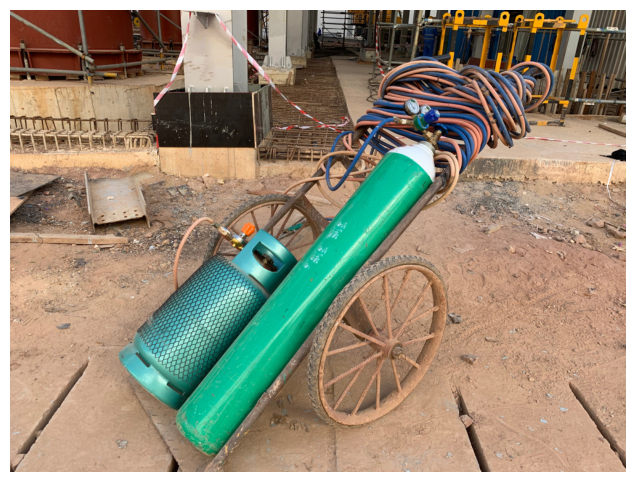

In [73]:
bboxes = [r["bbox"] for r in outcome]
image_with_bbox = draw_bboxes_and_show(image_path=img_path, bboxes=bboxes)
image_with_bbox.save(f"./imgs/results/yolo_world_1.jpg")

In [19]:
outcome

[{'bbox': [573, 125, 117, 236],
  'area': 27409.0996555225,
  'label': 'construction workers',
  'score': 0.25158971548080444}]

In [87]:
img_outcome = {}
for i, img_path in enumerate(img_path_list):
    outcome, image_size, inference_time = yoloworld_processor(model, img_path, caption)
    img_outcome[i] = {
        "img_path":img_path,
        "img_size":image_size, #[width, height]
        "inference_time":inference_time,
        "result":outcome
    }

In [88]:
with open(f"./results/yoloworld_{1}.json", "w") as fp:
    fp.write(json.dumps(img_outcome))

## 3. 测试代码

In [91]:
# model = YOLOWorld("YOLOv8l-worldv2.pt", verbose=False)
# model.set_classes(["gas tank", "oxygen tank"])
# # Save the model with the defined offline vocabulary
# results = model.predict("./imgs/testing.jpg", verbose=False)
# results[0].boxes